# Machine Learning for River Prediction (Exercise Notebook)

This notebook will guide you step-by-step through building and evaluating machine learning models to predict outcomes related to river data. Follow the instructions, complete the tasks, and fill in the code where indicated.

## 1. Introduction

In this exercise, you will:
- Obtain and merge datasets
- Create new features from the data
- Build, train, and evaluate different machine learning models
- Interpret and visualize the results

**Learning Objectives**:
- Understand how to work with data in a machine learning context.
- Learn how to combine and preprocess datasets.
- Train models such as Linear Regression, Decision Tree, and XGBoost.
- Compare model performances and interpret feature importance.

## 2. Data Acquisition and Preparation

### Task 1: Load the data
Use pandas to load the training and testing datasets provided. Each dataset represents a different time split of the same data.


In [188]:
import warnings
warnings.filterwarnings('ignore')

In [30]:
import pandas as pd

# Load the train and test datasets
df_train = pd.read_csv('data/train.csv', index_col=0)
df_test = pd.read_csv('data/test.csv', index_col=0)

# Tag each dataset to distinguish between them
df_train['tt'] = 'train'
df_test['tt'] = 'test'

### Task 2: Merge the datasets
Combine the training and test sets into one dataframe so that we can perform feature engineering on the entire dataset.


In [33]:
# Concatenate the train and test datasets
df = pd.concat([df_train, df_test])

# Display the first few rows to confirm the merge
df.head()

,year,month,day,hour,minute,surfaceHeight,tt
id,,,,,,,
0,2010,1,1,0,12,0.00,train
1,2010,1,1,0,59,-0.03,train
2,2010,1,1,1,15,-0.05,train
3,2010,1,1,1,18,-0.07,train
4,2010,1,1,1,42,-0.07,train


## 3. Feature Creation

### Task 3: Create new features
We will now create new features from the existing data that could improve the performance of our machine learning models.

**Guidelines for feature creation**:
- **Datetime Features**: Extract useful features from the timestamp, such as year, month, day, and hour.
- **Interactions**: Create new features by interacting existing ones (e.g., multiplication or ratios).
- **Aggregations**: If you have categories, compute averages, sums, or other statistics per category.


In [148]:
df['timestamp'] = pd.to_datetime(df[['year', 'month', 'day', 'hour','minute']])

In [149]:
df = df.set_index('timestamp')

In [150]:
import matplotlib.pyplot as plt

In [151]:
df

,year,month,day,hour,minute,surfaceHeight,tt,dayofyear,mean_daily_height
timestamp,,,,,,,,,
2010-01-01 00:12:00,2010,1,1,0,12,0.00,train,1,NaN
2010-01-01 00:59:00,2010,1,1,0,59,-0.03,train,1,NaN
2010-01-01 01:15:00,2010,1,1,1,15,-0.05,train,1,NaN
2010-01-01 01:18:00,2010,1,1,1,18,-0.07,train,1,NaN
2010-01-01 01:42:00,2010,1,1,1,42,-0.07,train,1,NaN
...,...,...,...,...,...,...,...,...,...
2023-11-15 14:15:00,2023,11,15,14,15,NaN,test,319,NaN
2023-11-15 14:20:00,2023,11,15,14,20,NaN,test,319,NaN
2023-11-15 14:25:00,2023,11,15,14,25,NaN,test,319,NaN


In [113]:
df['mean_daily_height'] = 0

In [189]:
for i in range(365):
    try:
        df.loc[df['dayofyear']==i,'mean_daily_height'] = df.loc[df['dayofyear']==i]['surfaceHeight'][0]
    except:
        pass

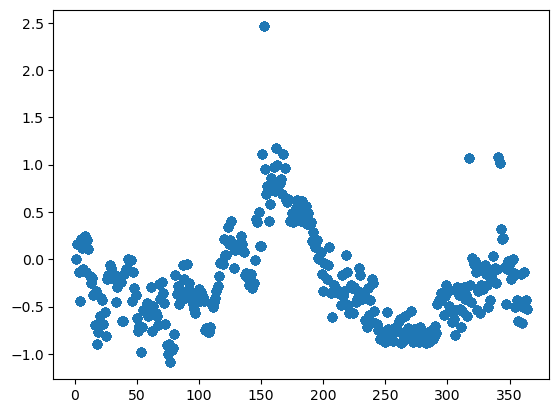

In [190]:
plt.scatter(df['dayofyear'],df['mean_daily_height'],alpha=0.01)

In [97]:
df['dayofyear'] = df.index.dayofyear

<AxesSubplot:xlabel='timestamp'>

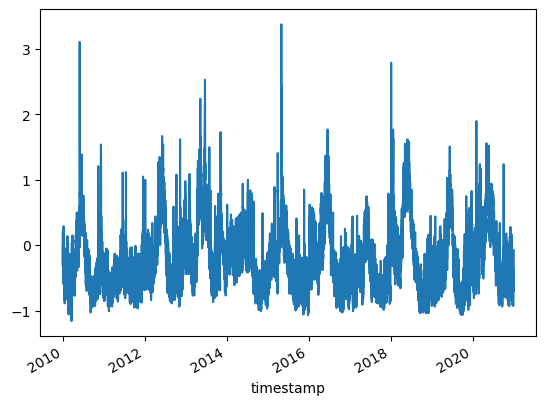

In [57]:
df['surfaceHeight'].plot()

In [45]:
df['dayofyear'] = df.index.dayofyear

In [42]:
df.dtypes

year               int64
month              int64
day                int64
hour               int64
minute             int64
surfaceHeight    float64
tt                object
dayofyear          int32
dtype: object

In [ ]:
# Example: Creating datetime-based features
df['year'] = pd.to_datetime(df['timestamp']).dt.year
df['month'] = pd.to_datetime(df['timestamp']).dt.month
df['day'] = pd.to_datetime(df['timestamp']).dt.day

# Create additional features as needed
# Example: interaction features
df['feature_interaction'] = df['feature1'] * df['feature2']

### Task 4: Handle missing values
Check for missing values and decide on a strategy to handle them (e.g., imputation, removal).


In [ ]:
# Check for missing values
df.isnull().sum()

# You can either fill missing values or drop rows/columns
# Example: filling missing values with the mean
df.fillna(df.mean(), inplace=True)

## 4. Data Splitting and Preprocessing

### Task 5: Split the data back into train and test sets
Now that we’ve processed the data, let's split it back into training and testing sets.


In [196]:
df = df.dropna()

In [197]:
# Split the combined dataset back into train and test sets
df_train = df[df['tt'] == 'train'].drop(columns=['tt'])
df_test = df[df['tt'] == 'test'].drop(columns=['tt'])

In [198]:
df_train_train = df.loc[df['year']<2020]
df_train_test = df.loc[df['year']==2020]

In [199]:
df_train_test

,year,month,day,hour,minute,surfaceHeight,tt,dayofyear,mean_daily_height
timestamp,,,,,,,,,
2020-01-01 00:36:00,2020,1,1,0,36,0.09,train,1,0.00
2020-01-01 01:03:00,2020,1,1,1,3,0.08,train,1,0.00
2020-01-01 03:09:00,2020,1,1,3,9,0.12,train,1,0.00
2020-01-01 04:06:00,2020,1,1,4,6,0.14,train,1,0.00
2020-01-01 04:57:00,2020,1,1,4,57,0.12,train,1,0.00
...,...,...,...,...,...,...,...,...,...
2020-12-29 18:42:00,2020,12,29,18,42,-0.36,train,364,-0.53
2020-12-29 20:36:00,2020,12,29,20,36,-0.39,train,364,-0.53
2020-12-29 21:21:00,2020,12,29,21,21,-0.37,train,364,-0.53


In [200]:
# Define X and y for both train and test sets
X_train = df_train_train.drop(columns=['surfaceHeight','tt'])  # Replace 'target_column' with your target variable
y_train = df_train_train['surfaceHeight']  # Replace 'target_column' with your target variable

X_test = df_train_test.drop(columns=['surfaceHeight','tt'])
y_test = df_train_test['surfaceHeight']

## 5. Model Training and Evaluation

### Task 6: Train a Linear Regression Model
Use `LinearRegression` from sklearn to fit the model and evaluate its performance.


In [201]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions and evaluate
y_linear_pred = model.predict(X_test)
linear_mse = mean_squared_error(y_test, y_linear_pred)
print(f'Linear Model Mean Squared Error: {linear_mse}')

Linear Model Mean Squared Error: 0.23098199588393395


In [202]:
df_train_test['y_linear_pred'] = model.predict(X_test)

Linear model prediction before adding mean_daily_height
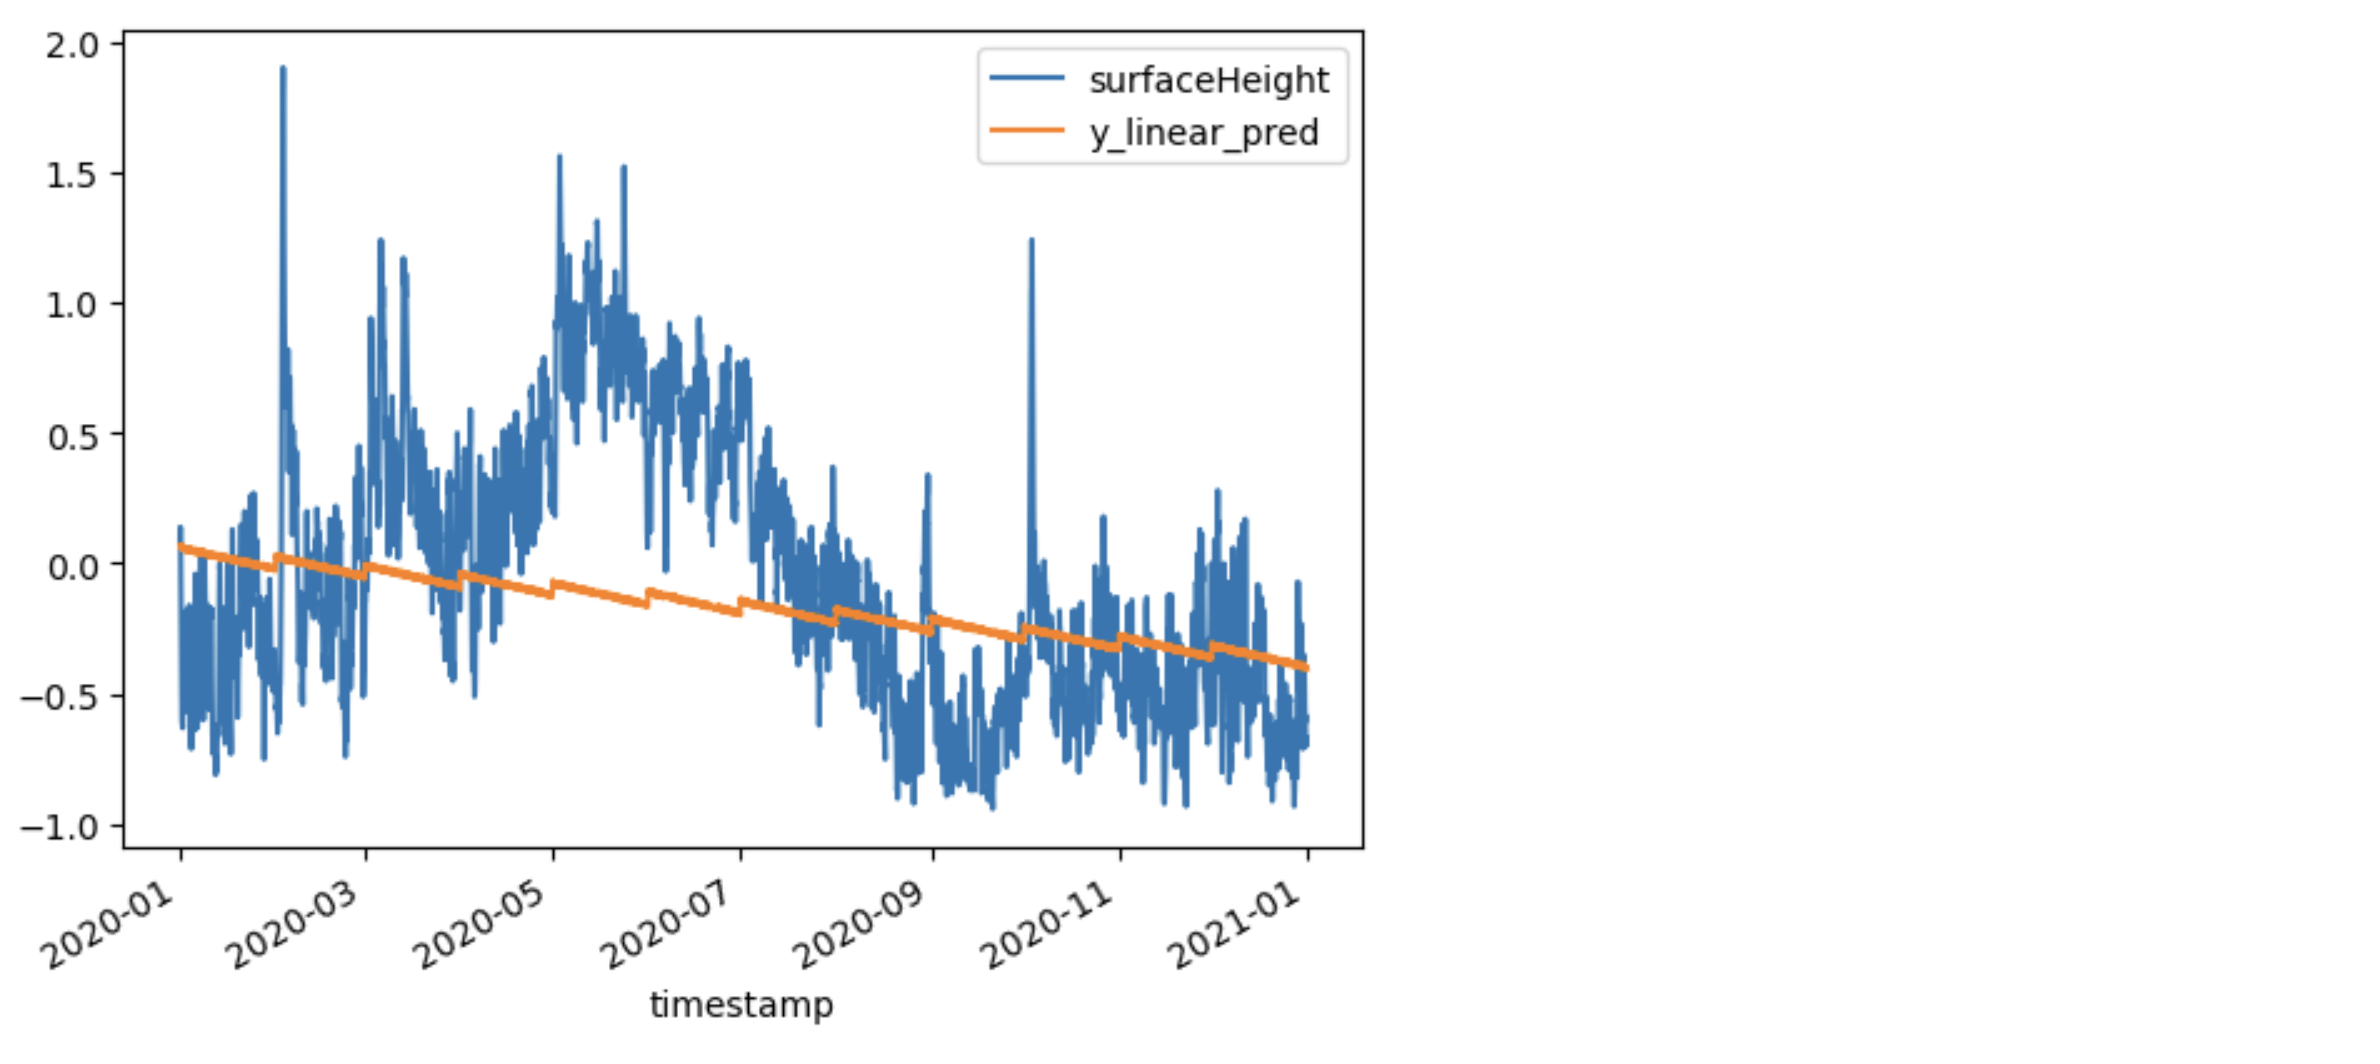

<AxesSubplot:xlabel='timestamp'>

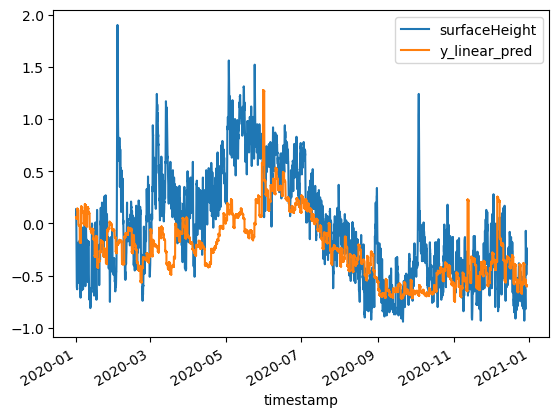

In [203]:
# linear model after adding the variable mean_daily_height
df_train_test[['surfaceHeight', 'y_linear_pred']].plot()

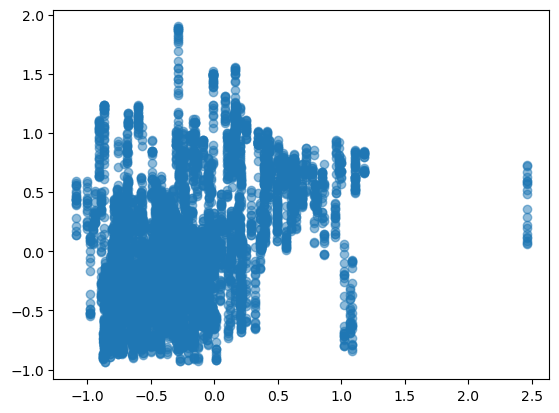

In [212]:
plt.scatter(df.loc[df['year']==2020]['mean_daily_height'],df.loc[df['year']==2020]['surfaceHeight'],alpha=0.5)

### Task 7: Train a Decision Tree Model
Repeat the steps to train a Decision Tree model and compare its performance.


In [204]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the model
tree_model = DecisionTreeRegressor()
tree_model.fit(X_train, y_train)

# Make predictions and evaluate
y_tree_pred = tree_model.predict(X_test)
tree_mse = mean_squared_error(y_test, y_tree_pred)
print(f'Decision Tree Mean Squared Error: {tree_mse}')

Decision Tree Mean Squared Error: 0.3266239195858914


In [205]:
df_train_test['y_tree_pred'] = tree_model.predict(X_test)

Tree and Linear model before adding mean_daily_height
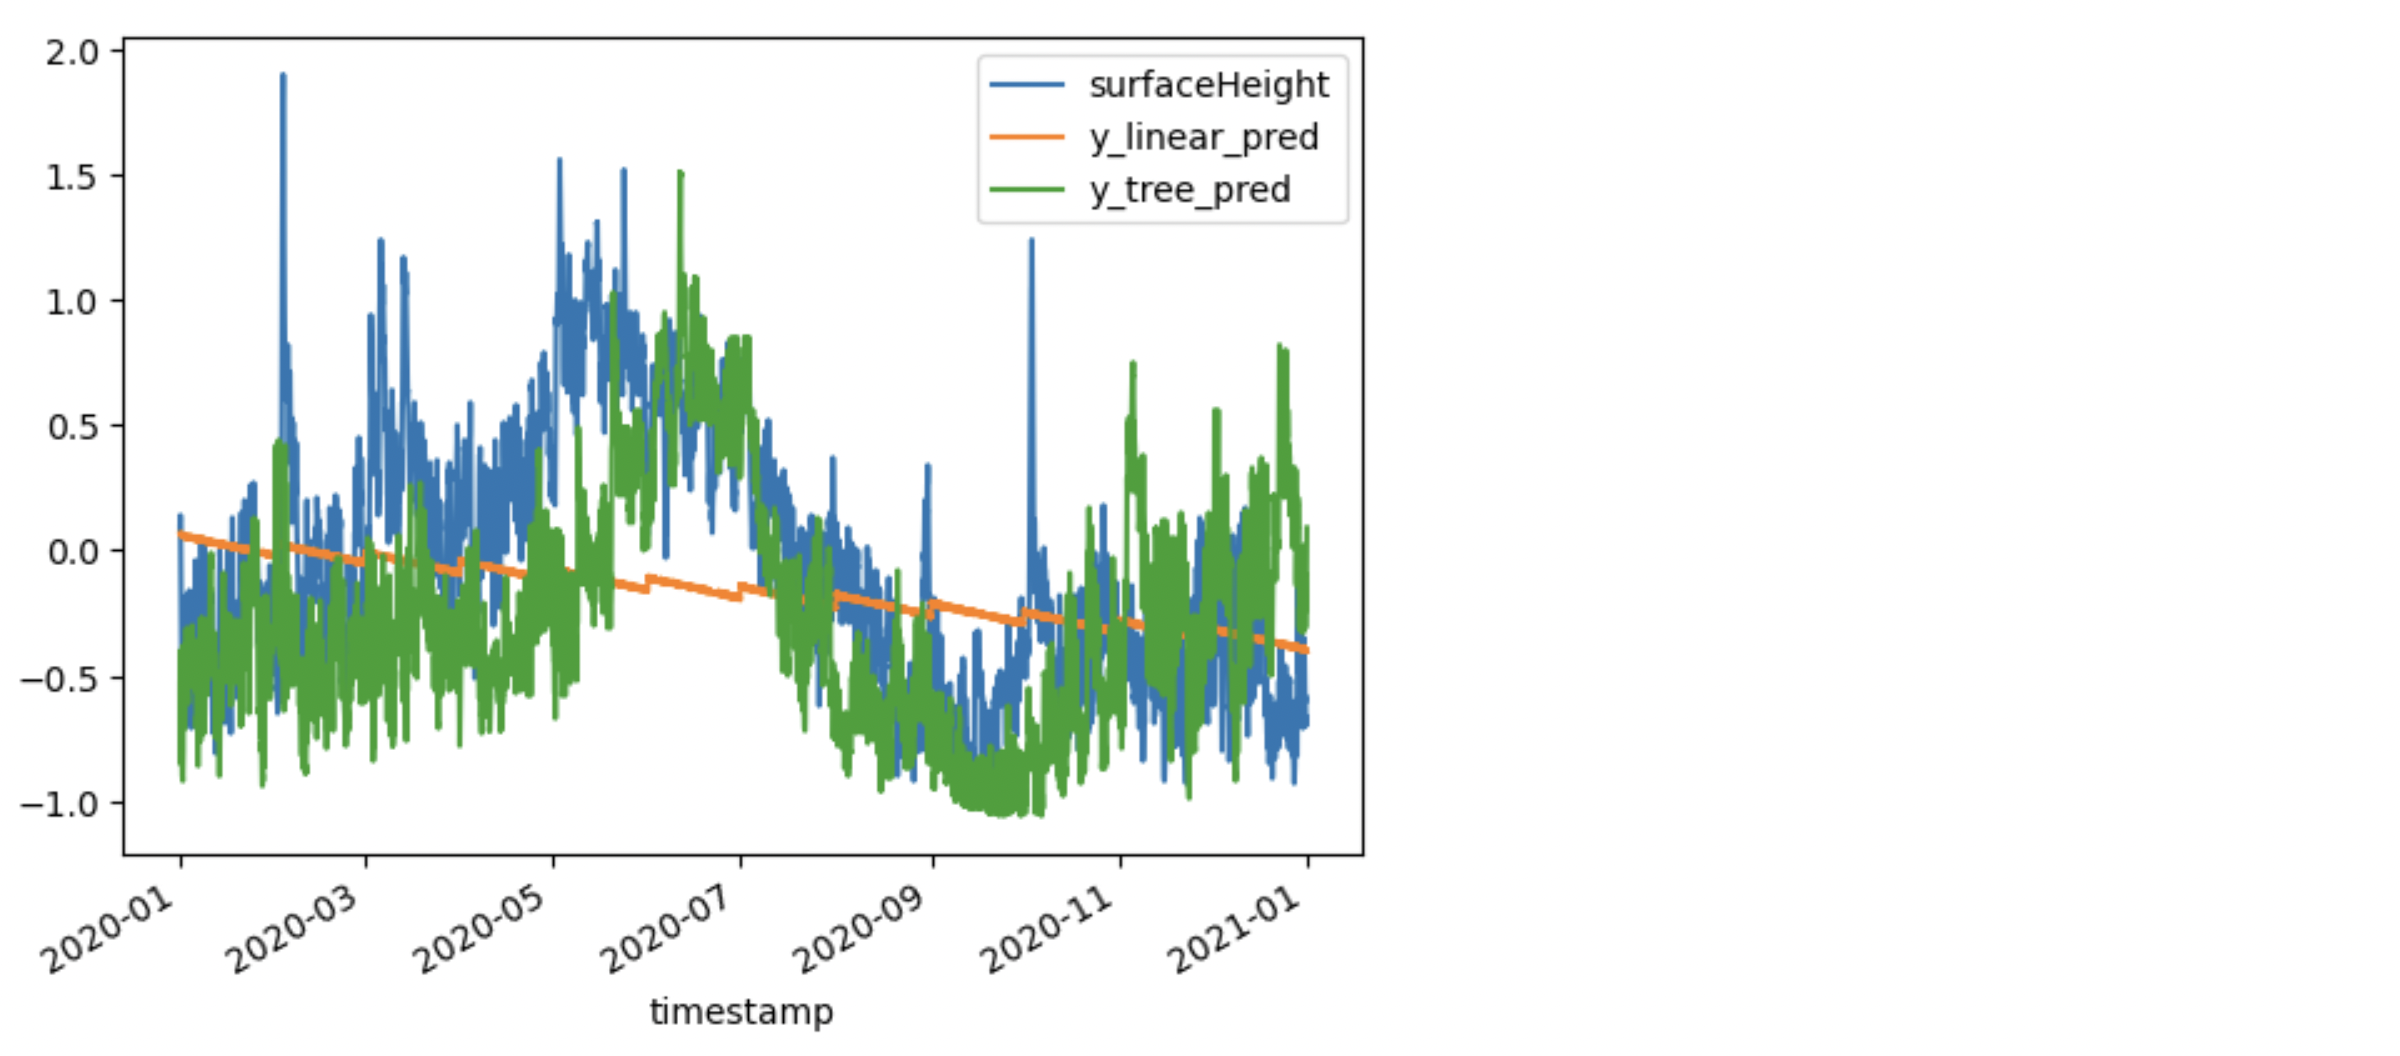

<AxesSubplot:xlabel='timestamp'>

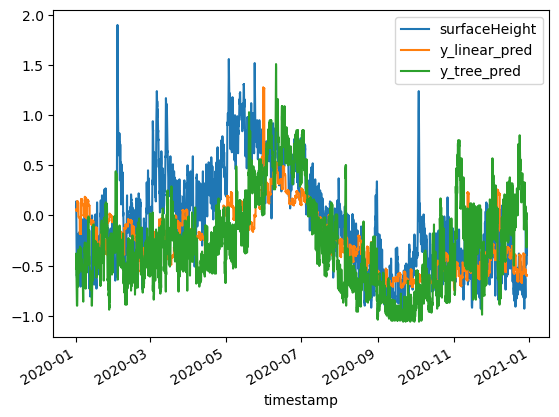

In [206]:
df_train_test[['surfaceHeight', 'y_linear_pred','y_tree_pred']].plot()

## 6. Feature Importance

### Task 8: Visualize feature importance
For the Decision Tree model, visualize the importance of each feature.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot feature importance
feature_names = X_train.columns
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_names)), tree_model.feature_importances_, align='center')
plt.yticks(np.arange(len(feature_names)), feature_names)
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

## 7. Challenge: Implement XGBoost

### Task 9: Train and evaluate an XGBoost model
A suggestion is to implement an XGBoost model. Train the model and evaluate its performance just as you did with the previous models.


In [ ]:
# Your XGBoost code here

# 8. Next Steps: Enrich your prediction with external data

You could potentially improve your model by incorporating additional datasets.
For example, if you're predicting river flow, you might want to look at:
- **Weather data**: Rainfall, temperature, humidity, etc.
    - Sources: OpenWeatherMap (API), NOAA Climate Data (https://www.ncdc.noaa.gov/cdo-web/), ECMWF (European Centre for Medium-Range Weather Forecasts)
- **Geographical data**: Elevation, land use, soil moisture.
    - Sources: USGS Earth Explorer (https://earthexplorer.usgs.gov/), NASA's Earth Data (https://earthdata.nasa.gov/)
- **Hydrological data**: River discharge, water levels.
    - Sources: Global Runoff Data Centre (https://www.bafg.de/GRDC/EN/Home/homepage_node.html), USGS Water Data (https://waterdata.usgs.gov/nwis)

Think about what external factors could affect the target variable you're trying to predict.
After you find a relevant dataset, consider how you can integrate it into your model.
- Could you merge the data on a common time index?
- Would this new data provide useful features (e.g., rainfall impacting river levels)?


## 8. Conclusion

Summarize your findings and reflect on the model performance:
- Which model performed the best?
- How important were the features in making predictions?
- What feature engineering steps made the biggest difference?
